In [1]:
import os
import glob
import re
from pypdf import PdfReader

# Resolve absolute path to data folder relative to notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
JD_DIR = os.path.join(BASE_DIR, "data", "raw", "jd")
RESUME_DIR = os.path.join(BASE_DIR, "data", "raw", "resumes")

def preprocess_text(text):
    if not text: return ""
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_and_clean_pdf(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        raw_text = ""
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted: raw_text += extracted + " "
        return preprocess_text(raw_text)
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return ""

real_jds = []
if os.path.exists(JD_DIR):
    for filepath in sorted(glob.glob(os.path.join(JD_DIR, "*.pdf"))):
        clean_text = extract_and_clean_pdf(filepath)
        if clean_text:
            real_jds.append({"id": os.path.basename(filepath), "text": clean_text[:2000]})

real_resumes = []
if os.path.exists(RESUME_DIR):
    for filepath in sorted(glob.glob(os.path.join(RESUME_DIR, "*.pdf"))):
        clean_text = extract_and_clean_pdf(filepath)
        if clean_text:
            real_resumes.append({"id": os.path.basename(filepath), "text": clean_text[:2000]})

print(f"Loaded and preprocessed {len(real_jds)} JDs and {len(real_resumes)} Resumes.")

Loaded and preprocessed 5 JDs and 4 Resumes.


In [2]:
import os
os.environ["HF_HUB_DISABLE_CONCURRENT_DOWNLOADS"] = "1"
os.environ["HF_HUB_MAX_WORKERS"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"   # fewer open file handles during download

import time, gc
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# make sure this is installed BEFORE running (pip install einops) — nomic's
# custom modeling code needs it, and a missing import here is the most
# likely root cause of the crash you hit.

real_models_to_test = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-small-en-v1.5",
    "BAAI/bge-large-en-v1.5",
    "BAAI/bge-m3",
    "nomic-ai/nomic-embed-text-v1.5",
    "sentence-transformers/bert-base-nli-mean-tokens"
]

real_benchmark_results = []
real_similarity_matrices = {}

jd_texts = [j["text"] for j in real_jds]
resume_texts = [r["text"] for r in real_resumes]

for model_name in real_models_to_test:
    print(f"Loading {model_name}...")
    model = None
    try:
        start_load = time.perf_counter()
        model = SentenceTransformer(model_name, trust_remote_code=True)
        load_time = time.perf_counter() - start_load

        prefix = "search_document: " if "nomic" in model_name else ""
        prefixed_jds = [prefix + t for t in jd_texts]
        prefixed_resumes = [prefix + t for t in resume_texts]

        start_embed = time.perf_counter()
        jd_embeddings = model.encode(prefixed_jds, normalize_embeddings=True)
        resume_embeddings = model.encode(prefixed_resumes, normalize_embeddings=True)
        embed_time = (time.perf_counter() - start_embed) * 1000

        sim_matrix = cosine_similarity(jd_embeddings, resume_embeddings)
        real_similarity_matrices[model_name] = sim_matrix

        real_benchmark_results.append({
            "Model": model_name.split("/")[-1],
            "Embedding Dim": jd_embeddings.shape[1],
            "Load Time (s)": round(load_time, 2),
            "Total Inference (ms)": round(embed_time, 2),
            "Avg Similarity Score": round(float(np.mean(sim_matrix)), 3)
        })
        print(f"  done — {model_name}")

    except Exception as e:
        print(f"  FAILED on {model_name}: {type(e).__name__}: {e}")
        continue  # one bad model doesn't kill the whole benchmark

    finally:
        if model is not None:
            del model
        gc.collect()

df_real_results = pd.DataFrame(real_benchmark_results)
print(f"\nCompleted {len(real_benchmark_results)}/{len(real_models_to_test)} models.")
df_real_results

Loading sentence-transformers/all-MiniLM-L6-v2...


  done — sentence-transformers/all-MiniLM-L6-v2
Loading BAAI/bge-small-en-v1.5...
  done — BAAI/bge-small-en-v1.5
Loading BAAI/bge-large-en-v1.5...
  done — BAAI/bge-large-en-v1.5
Loading BAAI/bge-m3...
  done — BAAI/bge-m3
Loading nomic-ai/nomic-embed-text-v1.5...


c:\Nivi\AIResumeAnalyser\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sayhe_j9xy\.cache\huggingface\hub\models--BAAI--bge-m3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Nivi\AIResumeAnalyser\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache

  done — nomic-ai/nomic-embed-text-v1.5
Loading sentence-transformers/bert-base-nli-mean-tokens...


c:\Nivi\AIResumeAnalyser\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sayhe_j9xy\.cache\huggingface\hub\models--sentence-transformers--bert-base-nli-mean-tokens. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  done — sentence-transformers/bert-base-nli-mean-tokens

Completed 6/6 models.


,Model,Embedding Dim,Load Time (s),Total Inference (ms),Avg Similarity Score
0,all-MiniLM-L6-v2,384,7.74,2089.22,0.306
1,bge-small-en-v1.5,384,7.24,3751.27,0.646
2,bge-large-en-v1.5,1024,7.06,44741.59,0.633
3,bge-m3,1024,14.40,39808.33,0.514
4,nomic-embed-text-v1.5,768,128.86,7942.30,0.643
5,bert-base-nli-mean-tokens,768,52.51,2008.18,0.641


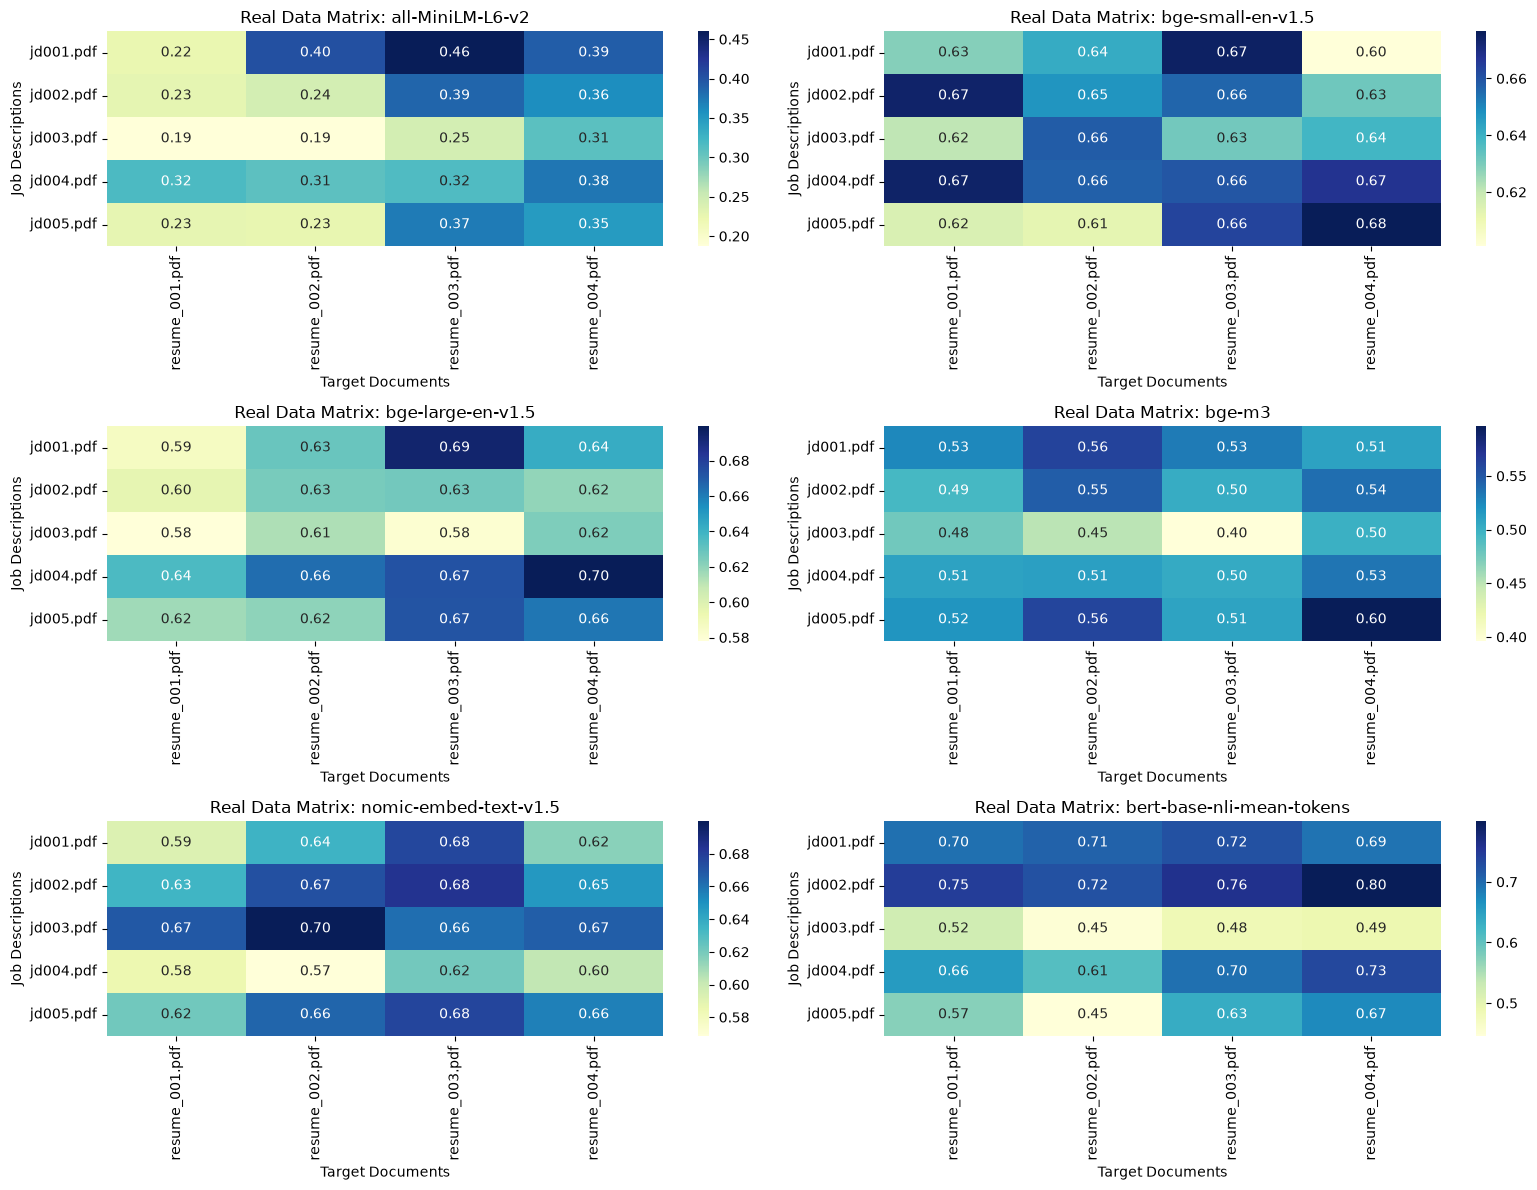

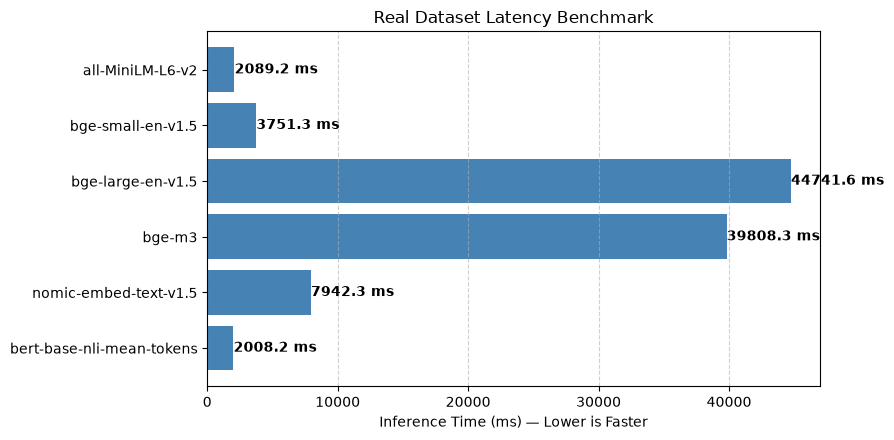

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Similarity Heatmaps — only for models that actually succeeded
completed_models = list(real_similarity_matrices.keys())
n = len(completed_models)
n_rows = (n + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n > 1 else [axes]

x_labels = [r["id"] for r in real_resumes]
y_labels = [j["id"] for j in real_jds]

for idx, model_name in enumerate(completed_models):
    short_name = model_name.split("/")[-1]
    sns.heatmap(
        real_similarity_matrices[model_name],
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        xticklabels=x_labels,
        yticklabels=y_labels,
        ax=axes[idx],
        cbar=True
    )
    axes[idx].set_title(f"Real Data Matrix: {short_name}")
    axes[idx].set_xlabel("Target Documents")
    axes[idx].set_ylabel("Job Descriptions")

# hide any unused subplot slots
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# 2. Latency Comparison Chart
plt.figure(figsize=(9, 4.5))
bars = plt.barh(df_real_results["Model"], df_real_results["Total Inference (ms)"], color="steelblue")
plt.xlabel("Inference Time (ms) — Lower is Faster")
plt.title("Real Dataset Latency Benchmark")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2, f"{width:.1f} ms", va='center', fontweight='bold')

plt.tight_layout()
plt.show()